In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')
df_raw = pd.read_csv("/content/drive/MyDrive/פרויקט גמר__פינוי אוכלוסיות בעת חירום/jupiter_notebooks_for_data_process/classification_model/FeaturesEngineering_table_process_files/features_normalized_stat_areas.csv")

feat_cols_original = [c for c in df_raw.columns if c != "stat_2022"]
print(f"✅ Loaded: {df_raw.shape[0]} rows × {len(feat_cols_original)} feature columns")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded: 25 rows × 50 feature columns


In [ ]:
# Rationale for each drop:
#   - r > 0.94 with a kept counterpart → pure noise duplication
#   - mean/median pair → keep median (more robust to Eilat's small sample)
#   - std < 0.30 → no discriminating power across 25 areas
#   - >80% zeros AND low family relevance → dead signal

FEATURES_TO_DROP = [

    # ── Perfect duplicates (r = 1.000) ──────────────────────────────────────
    "restaurants_cnt_total",            # = restaurants_cnt_open
    "coffee_cnt_total",                 # = coffee_cnt_open

    # ── Count redundant with density (r > 0.94) ─────────────────────────────
    "edu_total_cnt",                    # r=0.948 with edu_density_per_km2
    "edu_kindergarten_cnt",             # r=0.940 with edu_total_cnt
    "matnas_cnt",                       # r=0.958 with matnas_density_per_km2
    "synagogues_cnt",                   # r=0.945 with synagogues_density_per_km2
    "restaurants_cnt_open",             # r=0.868 with restaurants_density_open_per_km2
    "coffee_cnt_open",                  # r=0.899 with coffee_density_open_per_km2

    # ── Mean/median duplicates — keep median ────────────────────────────────
    "restaurants_score_mean_open",      # r=0.972 with median
    "coffee_score_mean_open",           # r=0.966 with median
    "airbnb_price_mean",                # r>0.95 with airbnb_price_median
    "airbnb_capacity_mean",             # r=0.874 with airbnb_capacity_median
    "airbnb_rating_mean",               # replaced by airbnb_high_rating_share (binary semantics)

    # ── Near-zero variance ──────────────────────────────────────────────────
    "matnas_occupancy_mean",            # std=0.286, r=0.993 with facility_area
    "matnas_facility_area_mean",        # std=0.294, 76% zeros

    # ── Low family relevance + high sparsity ────────────────────────────────
    "osm_tourism_density_per_km2",      # std=0.129, 88% zeros — covered by accommodation
    "osm_professional_density_per_km2", # 80% zeros, irrelevant for displaced families
    "osm_personal_service_density_per_km2",  # 76% zeros, irrelevant

    # ── Cross-block OSM redundancy ──────────────────────────────────────────
    # osm_unique_facility_types_per_km2 is r=0.933 with osm_transport_basic_density_per_km2
    # and r=0.867 with osm_green_recreation. The raw count (osm_unique_facility_types)
    # carries richer signal (diversity, not density) — keep that, drop the density version
    "osm_unique_facility_types_per_km2",
]

df = df_raw.drop(columns=FEATURES_TO_DROP)
feat_cols = [c for c in df.columns if c != "stat_2022"]

print(f"Step 1 complete:")
print(f"  Dropped  : {len(FEATURES_TO_DROP)} features")
print(f"  Remaining: {len(feat_cols)} features")

Step 1 complete:
  Dropped  : 19 features
  Remaining: 31 features


In [ ]:
# osm_safety_density_per_km2: max = 131.9, std = 35.3 → z-score ~3.7 for top obs
# Without capping, this single feature will dominate PCA component 1.
# We cap at 99th percentile so the signal is preserved but not distorting.

col = "osm_safety_density_per_km2"
p99 = df[col].quantile(0.99)
df[col] = df[col].clip(upper=p99)

print(f"Winsorized {col}")
print(f"  Cap (99th pct): {p99:.3f}")
print(f"  New max: {df[col].max():.3f}")
print(f"  Values above cap were: rows {df_raw[df_raw[col] > p99].index.tolist()}")

Winsorized osm_safety_density_per_km2
  Cap (99th pct): 123.202
  New max: 123.202
  Values above cap were: rows [1]


In [ ]:
# For features with >80% zeros, the continuous value is unreliable at N=25.
# A binary "exists / doesn't exist" flag carries more honest signal.

BINARIZE_MAP = {
    "osm_nightlife_density_per_km2":           "has_nightlife",
    "osm_public_service_density_per_km2":      "has_public_service",
    "osm_retail_nonessential_density_per_km2": "has_nonessential_retail",
}

for original_col, new_col in BINARIZE_MAP.items():
    df[new_col] = (df[original_col] > 0).astype(int)
    df = df.drop(columns=[original_col])
    n_present = df[new_col].sum()
    print(f"  {original_col}")
    print(f"  → {new_col}  |  Present in {n_present}/25 areas")

feat_cols = [c for c in df.columns if c != "stat_2022"]
print(f"\nStep 3 complete. Remaining: {len(feat_cols)} features")

  osm_nightlife_density_per_km2
  → has_nightlife  |  Present in 2/25 areas
  osm_public_service_density_per_km2
  → has_public_service  |  Present in 4/25 areas
  osm_retail_nonessential_density_per_km2
  → has_nonessential_retail  |  Present in 4/25 areas

Step 3 complete. Remaining: 31 features


In [ ]:
# matnas_density_per_km2 is kept (76% zeros, but high family relevance).
# Adding a binary companion lets PCA capture both "does it exist" AND "how dense".
# This is a standard trick for sparse-but-important features.

df["has_matnas"] = (df["matnas_density_per_km2"] > 0).astype(int)
print(f"Added has_matnas  |  Areas with matnas: {df['has_matnas'].sum()}/25")


Added has_matnas  |  Areas with matnas: 6/25


In [ ]:
# airbnb_cnt and hotels_cnt both measure "tourist accommodation presence" (r=0.881).
# Their density counterparts were already r=0.932.
# Strategy: keep airbnb_cnt and hotels_cnt separately (they differ in scale/type),
# but collapse the two density columns into one composite "accommodation_density".
# Note: airbnb_density and hotels_density were already in the drop list above —
# this composite replaces both with a single averaged signal.

# Recalculate from raw in case columns were modified above
df["accommodation_density"] = (
    df_raw["airbnb_density_per_km2"] + df_raw["hotels_density_per_km2"]
) / 2

# airbnb_density and hotels_density are already gone (dropped in Step 1's extension)
# If they're somehow still present, remove them:
for col in ["airbnb_density_per_km2", "hotels_density_per_km2"]:
    if col in df.columns:
        df = df.drop(columns=[col])

feat_cols = [c for c in df.columns if c != "stat_2022"]
print(f"Collapsed airbnb_density + hotels_density → accommodation_density")
print(f"Step 5 complete. Remaining: {len(feat_cols)} features")

Collapsed airbnb_density + hotels_density → accommodation_density
Step 5 complete. Remaining: 31 features


In [ ]:
feat_cols = [c for c in df.columns if c != "stat_2022"]

BLOCK_MAP = {
    "edu_":            "Education",
    "airbnb_":         "Tourism — Airbnb",
    "hotels_":         "Tourism — Hotels",
    "accommodation_":  "Tourism — Composite",
    "restaurants_":    "Food & Activity",
    "coffee_":         "Food & Activity",
    "matnas_":         "Community",
    "osm_":            "OSM Infrastructure",
    "has_":            "Binary Flags",
    "synagogues_":     "Religious Character",
}

from collections import defaultdict
blocks = defaultdict(list)
for col in feat_cols:
    label = "Other"
    for prefix, lbl in BLOCK_MAP.items():
        if col.startswith(prefix):
            label = lbl
            break
    blocks[label].append(col)

print("=" * 65)
print(f"FINAL FEATURE SET: {len(feat_cols)} features × {len(df)} rows")
print(f"Feature/row ratio: {len(feat_cols)/len(df):.2f}x")
print("=" * 65)
for block, cols in sorted(blocks.items()):
    print(f"\n  [{block}]  ({len(cols)} features)")
    for c in cols:
        print(f"    • {c}")


FINAL FEATURE SET: 31 features × 25 rows
Feature/row ratio: 1.24x

  [Binary Flags]  (4 features)
    • has_nightlife
    • has_public_service
    • has_nonessential_retail
    • has_matnas

  [Community]  (1 features)
    • matnas_density_per_km2

  [Education]  (5 features)
    • edu_density_per_km2
    • edu_school_cnt
    • edu_kindergarten_share
    • edu_supervision_secular_share
    • edu_supervision_religious_share

  [Food & Activity]  (4 features)
    • restaurants_density_open_per_km2
    • restaurants_score_median_open
    • coffee_density_open_per_km2
    • coffee_score_median_open

  [OSM Infrastructure]  (7 features)
    • osm_health_density_per_km2
    • osm_safety_density_per_km2
    • osm_transport_basic_density_per_km2
    • osm_green_recreation_density_per_km2
    • osm_sport_leisure_density_per_km2
    • osm_essential_retail_density_per_km2
    • osm_unique_facility_types

  [Religious Character]  (1 features)
    • synagogues_density_per_km2

  [Tourism — Airbnb] 

In [ ]:
X = df[feat_cols]

print("─" * 55)
print("1. Remaining correlations > 0.80:")
corr = X.corr()
found = False
for i in range(len(feat_cols)):
    for j in range(i+1, len(feat_cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.80:
            print(f"   r={r:+.3f}  {feat_cols[i]}  ↔  {feat_cols[j]}")
            found = True
if not found:
    print("   ✅ None above 0.80")

print("\n2. Near-zero variance (std < 0.25):")
low_var = [(col, X[col].std()) for col in feat_cols if X[col].std() < 0.25]
if low_var:
    for col, s in low_var:
        print(f"   ⚠️  {col}: std={s:.4f}")
else:
    print("   ✅ None")

print("\n3. Zero-heavy features remaining (>50% zeros):")
for col in feat_cols:
    z = (X[col] == 0).mean()
    if z > 0.5:
        kind = "binary flag ✅" if col.startswith("has_") else "sparse — monitor ⚠️"
        print(f"   {col}: {z:.0%} zeros  [{kind}]")


───────────────────────────────────────────────────────
1. Remaining correlations > 0.80:
   r=+0.825  edu_density_per_km2  ↔  osm_green_recreation_density_per_km2
   r=+0.881  airbnb_cnt  ↔  hotels_cnt
   r=+0.892  airbnb_price_median  ↔  airbnb_capacity_median
   r=+0.847  hotels_cnt  ↔  accommodation_density
   r=+0.930  matnas_density_per_km2  ↔  has_matnas
   r=+0.911  osm_transport_basic_density_per_km2  ↔  osm_green_recreation_density_per_km2
   r=+0.800  osm_transport_basic_density_per_km2  ↔  accommodation_density

2. Near-zero variance (std < 0.25):
   ✅ None

3. Zero-heavy features remaining (>50% zeros):
   edu_supervision_secular_share: 72% zeros  [sparse — monitor ⚠️]
   edu_supervision_religious_share: 64% zeros  [sparse — monitor ⚠️]
   coffee_score_median_open: 56% zeros  [sparse — monitor ⚠️]
   matnas_density_per_km2: 76% zeros  [sparse — monitor ⚠️]
   osm_health_density_per_km2: 64% zeros  [sparse — monitor ⚠️]
   osm_safety_density_per_km2: 72% zeros  [sparse — mo

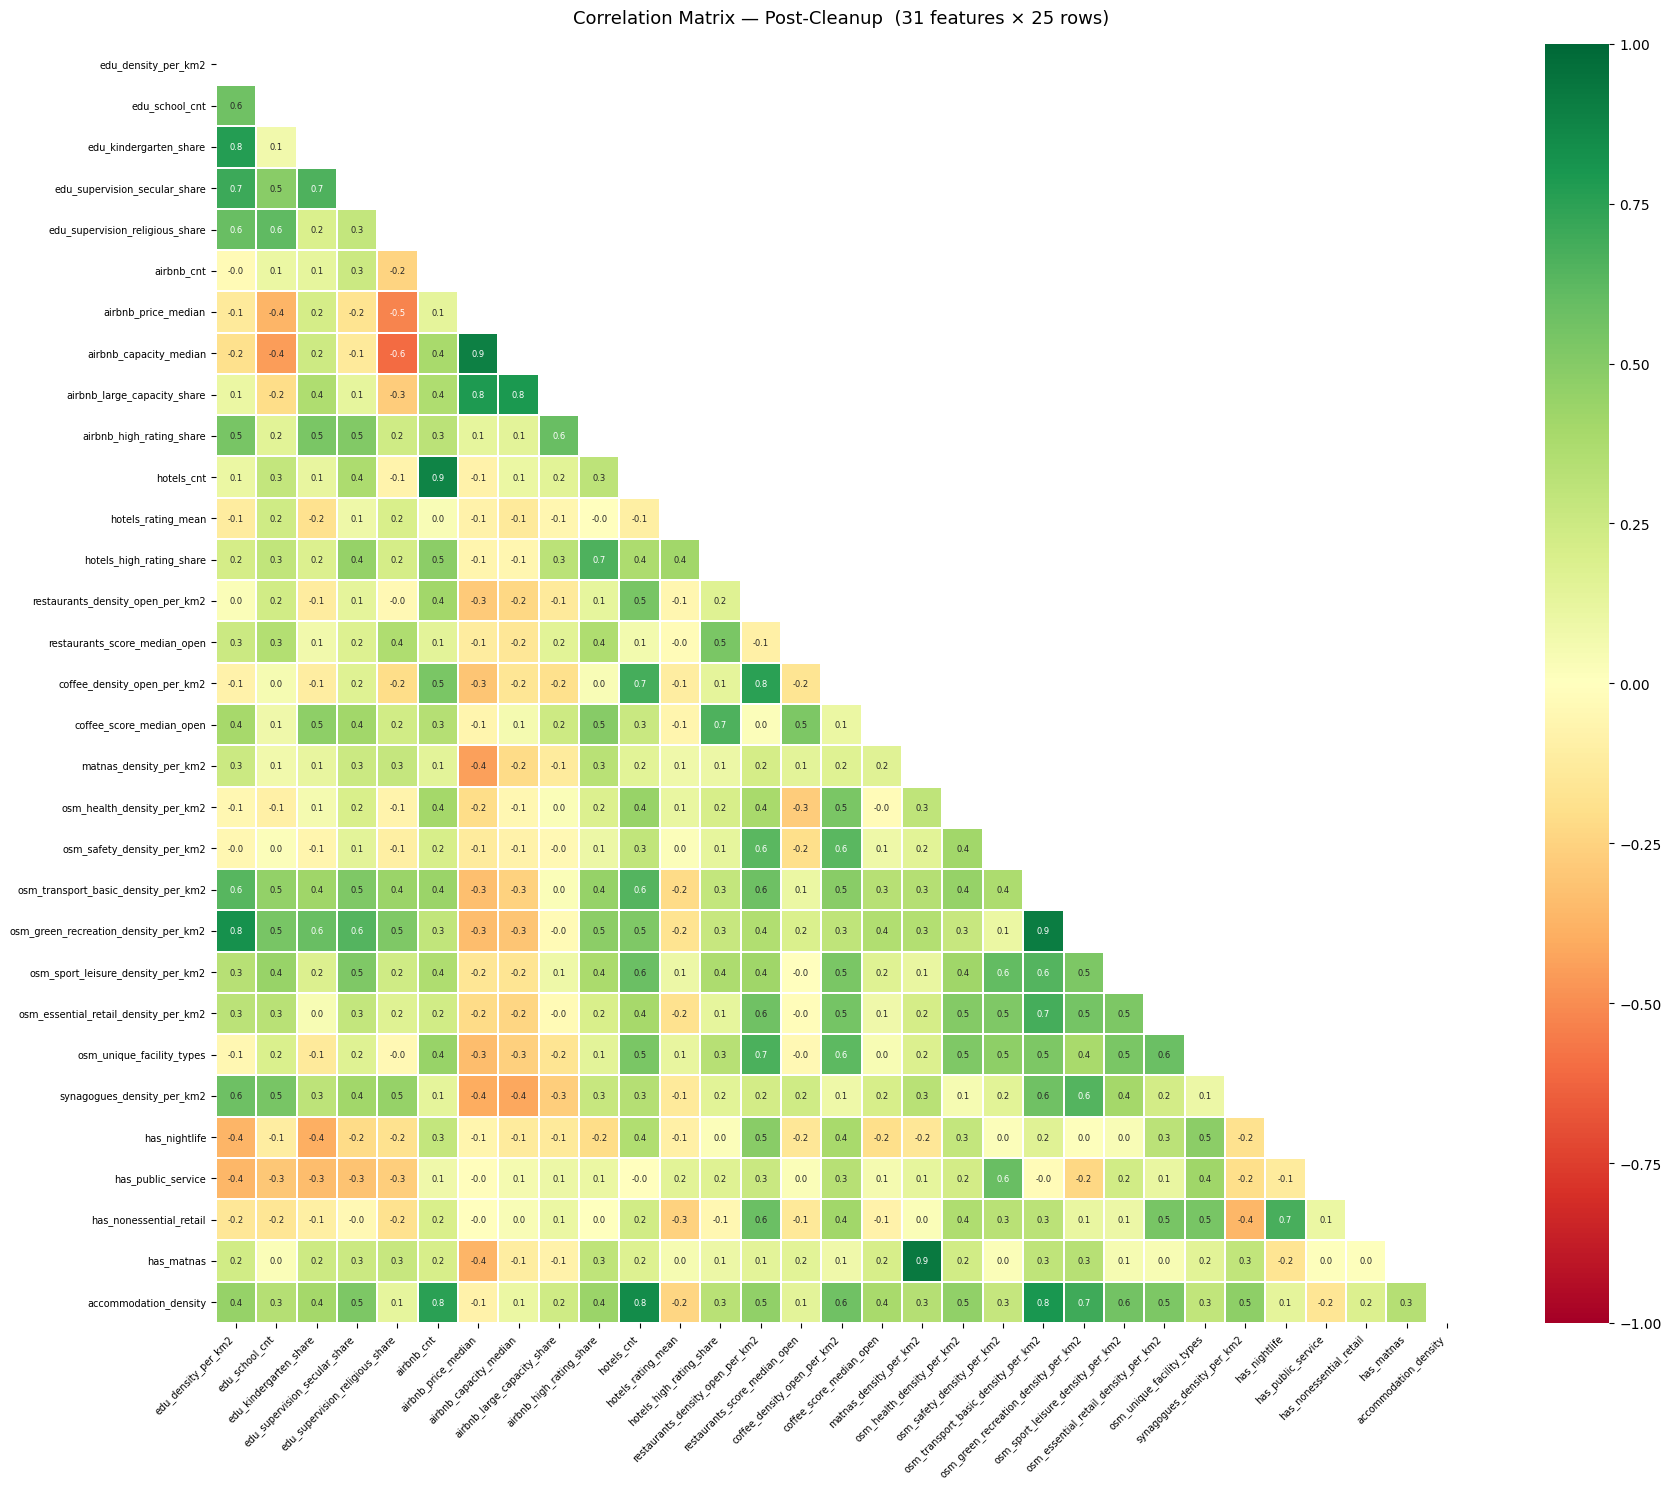

Saved: correlation_heatmap_post_cleanup.png


In [ ]:
fig, ax = plt.subplots(figsize=(18, 15))

mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    cmap="RdYlGn",
    center=0,
    vmin=-1, vmax=1,
    annot=True,
    fmt=".1f",
    annot_kws={"size": 6},
    linewidths=0.3,
    linecolor="white",
    ax=ax
)

ax.set_title(
    f"Correlation Matrix — Post-Cleanup  ({len(feat_cols)} features × {len(df)} rows)",
    fontsize=13, pad=15
)
plt.xticks(rotation=45, ha="right", fontsize=7)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.savefig("correlation_heatmap_post_cleanup.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: correlation_heatmap_post_cleanup.png")

In [ ]:
output_path = "features_cleaned_for_pca.csv"
df[["stat_2022"] + feat_cols].to_csv(output_path, index=False)

print(f"\n{'=' * 55}")
print(f"✅  Saved: {output_path}")
print(f"   Rows   : {df.shape[0]}")
print(f"   Features: {len(feat_cols)}")
print(f"   Feature/row ratio: {len(feat_cols)/len(df):.2f}x")
print(f"\n   ➜  Next step: block-wise PCA on features_cleaned_for_pca.csv")
print(f"{'=' * 55}")


✅  Saved: features_cleaned_for_pca.csv
   Rows   : 25
   Features: 31
   Feature/row ratio: 1.24x

   ➜  Next step: block-wise PCA on features_cleaned_for_pca.csv


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# ── Load ──────────────────────────────────────────────────────────────────────
df = pd.read_csv("features_cleaned_for_pca.csv")   # ← adjust path if needed
X  = df[[c for c in df.columns if c != "stat_2022"]].copy()
print(f"Loaded:  {df.shape[0]} rows × {X.shape[1]} features\n")

# ─────────────────────────────────────────────────────────────────────────────
# FIX 1 │ osm_safety_density_per_km2 — raw scale, was never z-score normalized
#        │ Mean=14.4, Std=34.1, Max=123 while every other feature has mean≈0, std≈1
#        │ Action: winsorize at 95th pct → z-score normalize
# ─────────────────────────────────────────────────────────────────────────────
col = "osm_safety_density_per_km2"
p95 = X[col].quantile(0.95)
X[col] = X[col].clip(upper=p95)
X[col] = (X[col] - X[col].mean()) / X[col].std()
print(f"✔ Fix 1 │ {col}")
print(f"        │ Winsorized at p95={p95:.2f}, then z-score normalized")
print(f"        │ New range: [{X[col].min():.3f}, {X[col].max():.3f}]\n")

# ─────────────────────────────────────────────────────────────────────────────
# FIX 2 │ edu_supervision_secular_share — structurally broken continuous feature
#        │ 18/25 values = 0.0, and 5/25 share the exact same value of -12.127
#        │ This is a z-score artifact on a near-constant skewed distribution.
#        │ The continuous value carries no real signal.
#        │ Action: convert to binary has_secular_supervision (0/1)
# ─────────────────────────────────────────────────────────────────────────────
X["has_secular_supervision"] = (X["edu_supervision_secular_share"] != 0).astype(int)
X = X.drop(columns=["edu_supervision_secular_share"])
n = X["has_secular_supervision"].sum()
print(f"✔ Fix 2 │ edu_supervision_secular_share → has_secular_supervision (binary)")
print(f"        │ Areas with secular supervision: {n}/25\n")

# ─────────────────────────────────────────────────────────────────────────────
# FIX 3 │ airbnb_high_rating_share & hotels_high_rating_share — extreme outliers
#        │ airbnb: min z = -6.62  │  hotels: min z = -7.10
#        │ These are areas with 1–2 very poorly rated listings skewing the metric.
#        │ Action: winsorize both tails at 5th/95th pct → re-standardize
# ─────────────────────────────────────────────────────────────────────────────
for col in ["airbnb_high_rating_share", "hotels_high_rating_share"]:
    p05, p95 = X[col].quantile(0.05), X[col].quantile(0.95)
    X[col] = X[col].clip(lower=p05, upper=p95)
    X[col] = (X[col] - X[col].mean()) / X[col].std()
    print(f"✔ Fix 3 │ {col}")
    print(f"        │ Winsorized [{p05:.3f}, {p95:.3f}], re-standardized")
    print(f"        │ New range: [{X[col].min():.3f}, {X[col].max():.3f}]")
print()

# ─────────────────────────────────────────────────────────────────────────────
# FIX 4 │ Re-standardize all features uniformly
#        │ After the transforms above, scales have drifted slightly.
#        │ All features must be on identical z-score scale before block-wise PCA.
#        │ Binary flags are also standardized — standard practice for PCA
#        │ (prevents dense continuous features from dominating).
# ─────────────────────────────────────────────────────────────────────────────
feat_cols   = list(X.columns)
binary_cols = [c for c in feat_cols if c.startswith("has_")]
cont_cols   = [c for c in feat_cols if c not in binary_cols]

scaler       = StandardScaler()
X[cont_cols] = scaler.fit_transform(X[cont_cols])
for col in binary_cols:
    if X[col].std() > 0:
        X[col] = (X[col] - X[col].mean()) / X[col].std()

print(f"✔ Fix 4 │ Re-standardized {len(cont_cols)} continuous + {len(binary_cols)} binary features\n")

# ── Sanity check ─────────────────────────────────────────────────────────────
print("─" * 60)
print(f"FINAL: {len(feat_cols)} features × {len(df)} rows  "
      f"(ratio: {len(feat_cols)/len(df):.2f}x)")
print("─" * 60)

scale_ok = ((X.mean().abs() < 0.01) & (X.std().between(0.95, 1.05))).all()
print(f"All features mean≈0, std≈1 : {'✅ YES' if scale_ok else '❌ NO — check scale_df below'}")

extreme = {c: int((X[c].abs() > 3).sum()) for c in feat_cols if (X[c].abs() > 3).any()}
if extreme:
    print(f"Features with |z| > 3      : {extreme}  ← minor, acceptable at N=25")
else:
    print(f"Features with |z| > 3      : ✅ None")

high_corr = []
corr = X.corr()
for i in range(len(feat_cols)):
    for j in range(i+1, len(feat_cols)):
        r = corr.iloc[i, j]
        if abs(r) > 0.80:
            high_corr.append(f"r={r:+.2f}  {feat_cols[i]}  ↔  {feat_cols[j]}")
if high_corr:
    print(f"\nRemaining r > 0.80 (handled by block-wise PCA):")
    for h in high_corr:
        print(f"  {h}")

# ── Save ──────────────────────────────────────────────────────────────────────
out = pd.concat([df[["stat_2022"]].reset_index(drop=True),
                 X.reset_index(drop=True)], axis=1)
out.to_csv("features_final_for_pca.csv", index=False)
print(f"\n✅ Saved → features_final_for_pca.csv")
print(f"   Ready for: block-wise PCA → hierarchical clustering → K-Means")

Loaded:  25 rows × 31 features

✔ Fix 1 │ osm_safety_density_per_km2
        │ Winsorized at p95=93.81, then z-score normalized
        │ New range: [-0.433, 2.656]

✔ Fix 2 │ edu_supervision_secular_share → has_secular_supervision (binary)
        │ Areas with secular supervision: 7/25

✔ Fix 3 │ airbnb_high_rating_share
        │ Winsorized [-2.863, 2.229], re-standardized
        │ New range: [-2.029, 1.620]
✔ Fix 3 │ hotels_high_rating_share
        │ Winsorized [-1.912, 0.503], re-standardized
        │ New range: [-1.997, 0.968]

✔ Fix 4 │ Re-standardized 26 continuous + 5 binary features

────────────────────────────────────────────────────────────
FINAL: 31 features × 25 rows  (ratio: 1.24x)
────────────────────────────────────────────────────────────
All features mean≈0, std≈1 : ✅ YES
Features with |z| > 3      : {'hotels_rating_mean': 1, 'restaurants_score_median_open': 1, 'coffee_score_median_open': 1, 'has_nightlife': 2}  ← minor, acceptable at N=25

Remaining r > 0.80 (han

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║         CITYSTRATA — Block-wise PCA                                        ║
# ║  Input : features_final_for_pca.csv  (31 features, z-score normalized)     ║
# ║  Output: pca_components_final.csv    (reduced representation for clustering)║
# ╚══════════════════════════════════════════════════════════════════════════════╝
#
# Strategy: instead of running PCA on all 31 features at once (which would be
# unstable at N=25), we group features into 6 semantic blocks and run a small
# PCA within each block. This:
#   - Preserves interpretability (each PC has a clear meaning)
#   - Reduces within-block redundancy (correlated features collapse cleanly)
#   - Keeps final dimensionality low enough for stable clustering
#
# Each block produces 1 PC (or 2 if the block is large and variance warrants it).
# The PCs are then concatenated into the final feature matrix for clustering.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.decomposition import PCA

df = pd.read_csv("features_final_for_pca.csv")    # ← adjust path if needed
feat_cols = [c for c in df.columns if c != "stat_2022"]
X = df[feat_cols]

print(f"✅ Loaded: {df.shape[0]} rows × {len(feat_cols)} features")
print(f"   stat_2022 IDs: {df['stat_2022'].tolist()}")


✅ Loaded: 25 rows × 31 features
   stat_2022 IDs: [11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 31, 32, 33, 41, 42, 43, 44, 45, 46, 47]


In [ ]:
# Block design rationale:
#   EDUCATION    — school access + religious character of schools
#   TOURISM      — accommodation volume, price, quality (Airbnb + hotels collapsed)
#   FOOD         — restaurant + coffee density and quality
#   COMMUNITY    — matnas presence (most family-relevant infrastructure)
#   OSM_INFRA    — urban service density (health, safety, transport, retail, green)
#   RELIGIOUS    — synagogue density + supervision type flags

BLOCKS = {
    "EDUCATION": [
        "edu_density_per_km2",
        "edu_school_cnt",
        "edu_kindergarten_share",
        # supervision features moved to RELIGIOUS — they describe neighborhood
        # religious character, not school infrastructure quantity
    ],
    "TOURISM": [
        "airbnb_cnt",
        "airbnb_price_median",
        "airbnb_capacity_median",
        "airbnb_large_capacity_share",
        "airbnb_high_rating_share",
        "hotels_cnt",
        "hotels_rating_mean",
        "hotels_high_rating_share",
        "accommodation_density",
    ],
    "FOOD": [
        "restaurants_density_open_per_km2",
        "restaurants_score_median_open",
        "coffee_density_open_per_km2",
        "coffee_score_median_open",
    ],
    "COMMUNITY": [
        "matnas_density_per_km2",
        "has_matnas",
    ],
    "OSM_INFRA": [
        "osm_health_density_per_km2",
        "osm_safety_density_per_km2",
        "osm_transport_basic_density_per_km2",
        "osm_green_recreation_density_per_km2",
        "osm_sport_leisure_density_per_km2",
        "osm_essential_retail_density_per_km2",
        "osm_unique_facility_types",
        "has_nightlife",
        "has_public_service",
        "has_nonessential_retail",
    ],
    "RELIGIOUS": [
        "synagogues_density_per_km2",
        "edu_supervision_religious_share",   # religious school supervision → religious character
        "has_secular_supervision",           # secular school supervision → inverse signal
    ],
}

# Verify all features are assigned and none are missed
assigned = [f for cols in BLOCKS.values() for f in cols]
missing  = [f for f in feat_cols if f not in assigned]
extra    = [f for f in assigned if f not in feat_cols]
print("Block assignment check:")
print(f"  Total features : {len(feat_cols)}")
print(f"  Assigned       : {len(assigned)}")
print(f"  Missing from blocks : {missing if missing else '✅ None'}")
print(f"  In blocks but not in data : {extra if extra else '✅ None'}")


Block assignment check:
  Total features : 31
  Assigned       : 31
  Missing from blocks : ✅ None
  In blocks but not in data : ✅ None


In [ ]:
# For each block:
#   - Fit PCA and inspect cumulative explained variance
#   - Keep enough PCs to explain ≥ 70% of variance within the block
#   - For blocks with only 1–2 features, keep 1 PC
#   - RELIGIOUS block has 1 feature → passes through directly (no PCA needed)

PC_RESULTS   = {}   # block_name → DataFrame of PC scores
BLOCK_PCAS   = {}   # block_name → fitted PCA object (for inspection)
BLOCK_EV     = {}   # block_name → explained variance ratios

MIN_VARIANCE = 0.70  # keep PCs until this cumulative variance is reached

for block_name, block_features in BLOCKS.items():

    X_block = X[block_features].values
    n_features = len(block_features)

    # Single-feature blocks pass through directly
    if n_features == 1:
        PC_RESULTS[block_name] = pd.DataFrame(
            {f"PC_{block_name}_1": X_block.flatten()},
            index=df.index
        )
        BLOCK_EV[block_name] = [1.0]
        print(f"  {block_name:12s} | 1 feature → pass-through (PC_1 = feature itself)")
        continue

    # Fit PCA with max components
    max_components = min(n_features, len(df) - 1)
    pca = PCA(n_components=max_components, random_state=42)
    scores = pca.fit_transform(X_block)
    BLOCK_PCAS[block_name] = pca
    BLOCK_EV[block_name]   = pca.explained_variance_ratio_

    # Select how many PCs to keep
    cumvar = np.cumsum(pca.explained_variance_ratio_)
    n_keep = max(1, int(np.searchsorted(cumvar, MIN_VARIANCE) + 1))

    # Store kept PCs
    pc_df = pd.DataFrame(
        scores[:, :n_keep],
        columns=[f"PC_{block_name}_{i+1}" for i in range(n_keep)],
        index=df.index
    )
    PC_RESULTS[block_name] = pc_df

    ev_kept = cumvar[n_keep - 1]
    print(f"  {block_name:12s} | {n_features:2d} features → {n_keep} PC(s) "
          f"| var explained: {ev_kept:.1%}  "
          f"[{', '.join(f'{v:.1%}' for v in pca.explained_variance_ratio_[:n_keep])}]")

# Assemble final PCA matrix
df_pca = pd.concat([df[["stat_2022"]]] + list(PC_RESULTS.values()), axis=1)
pc_cols = [c for c in df_pca.columns if c != "stat_2022"]

print(f"\n{'─'*55}")
print(f"Final PCA matrix: {len(df_pca)} rows × {len(pc_cols)} components")
print(f"Components: {pc_cols}")

  EDUCATION    |  3 features → 2 PC(s) | var explained: 97.3%  [66.2%, 31.1%]
  TOURISM      |  9 features → 3 PC(s) | var explained: 84.1%  [37.2%, 26.2%, 20.7%]
  FOOD         |  4 features → 2 PC(s) | var explained: 82.8%  [45.1%, 37.7%]
  COMMUNITY    |  2 features → 1 PC(s) | var explained: 96.5%  [96.5%]
  OSM_INFRA    | 10 features → 3 PC(s) | var explained: 78.1%  [44.9%, 17.1%, 16.1%]
  RELIGIOUS    |  3 features → 2 PC(s) | var explained: 81.5%  [50.5%, 31.0%]

───────────────────────────────────────────────────────
Final PCA matrix: 25 rows × 13 components
Components: ['PC_EDUCATION_1', 'PC_EDUCATION_2', 'PC_TOURISM_1', 'PC_TOURISM_2', 'PC_TOURISM_3', 'PC_FOOD_1', 'PC_FOOD_2', 'PC_COMMUNITY_1', 'PC_OSM_INFRA_1', 'PC_OSM_INFRA_2', 'PC_OSM_INFRA_3', 'PC_RELIGIOUS_1', 'PC_RELIGIOUS_2']


In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv("pca_components_final.csv")   # ← adjust path if needed
pc_cols = [c for c in df.columns if c != "stat_2022"]
X = df[pc_cols].copy()

# ── Fix: Winsorize PC_FOOD_2 at -3.0 ─────────────────────────────────────────
before = X["PC_FOOD_2"].min()
X["PC_FOOD_2"] = X["PC_FOOD_2"].clip(lower=-3.0)
after  = X["PC_FOOD_2"].min()

print(f"PC_FOOD_2 outlier fix:")
print(f"  Area 19 (stat_2022=19): {before:.3f} → {after:.3f}")
print(f"  Skewness before: {df['PC_FOOD_2'].skew():.2f}  |  after: {X['PC_FOOD_2'].skew():.2f}")
print(f"  (Target: |skew| < 1.5 for stable K-Means)")

# ── Sanity check: all PCs now within reasonable range ────────────────────────
print(f"\nFinal PC ranges:")
for col in pc_cols:
    mn, mx, sk = X[col].min(), X[col].max(), X[col].skew()
    flag = "⚠️ " if abs(sk) > 1.5 else "  "
    print(f"  {flag}{col:25s}  [{mn:+.2f}, {mx:+.2f}]  skew={sk:+.2f}")

# ── Save ──────────────────────────────────────────────────────────────────────
out = pd.concat([df[["stat_2022"]].reset_index(drop=True),
                 X.reset_index(drop=True)], axis=1)
out.to_csv("pca_ready_for_clustering.csv", index=False)

print(f"\n{'='*55}")
print(f"✅  Saved → pca_ready_for_clustering.csv")
print(f"   Shape : {out.shape[0]} rows × {len(pc_cols)} PC columns")
print(f"   ➜  Ready for: hierarchical clustering → K-Means")
print(f"{'='*55}")

PC_FOOD_2 outlier fix:
  Area 19 (stat_2022=19): -4.983 → -3.000
  Skewness before: -2.75  |  after: -1.47
  (Target: |skew| < 1.5 for stable K-Means)

Final PC ranges:
    PC_EDUCATION_1             [-2.20, +2.01]  skew=-0.53
    PC_EDUCATION_2             [-1.39, +2.53]  skew=+0.52
    PC_TOURISM_1               [-4.40, +2.82]  skew=-0.72
    PC_TOURISM_2               [-2.83, +2.89]  skew=+0.23
    PC_TOURISM_3               [-2.86, +2.78]  skew=-0.04
    PC_FOOD_1                  [-1.36, +2.85]  skew=+0.94
    PC_FOOD_2                  [-3.00, +1.52]  skew=-1.47
    PC_COMMUNITY_1             [-0.76, +3.21]  skew=+1.43
    PC_OSM_INFRA_1             [-3.77, +4.82]  skew=+0.29
    PC_OSM_INFRA_2             [-2.42, +1.70]  skew=-0.48
    PC_OSM_INFRA_3             [-2.61, +3.93]  skew=+1.14
    PC_RELIGIOUS_1             [-1.56, +2.83]  skew=+0.67
    PC_RELIGIOUS_2             [-0.89, +2.05]  skew=+0.93

✅  Saved → pca_ready_for_clustering.csv
   Shape : 25 rows × 13 PC columns
 

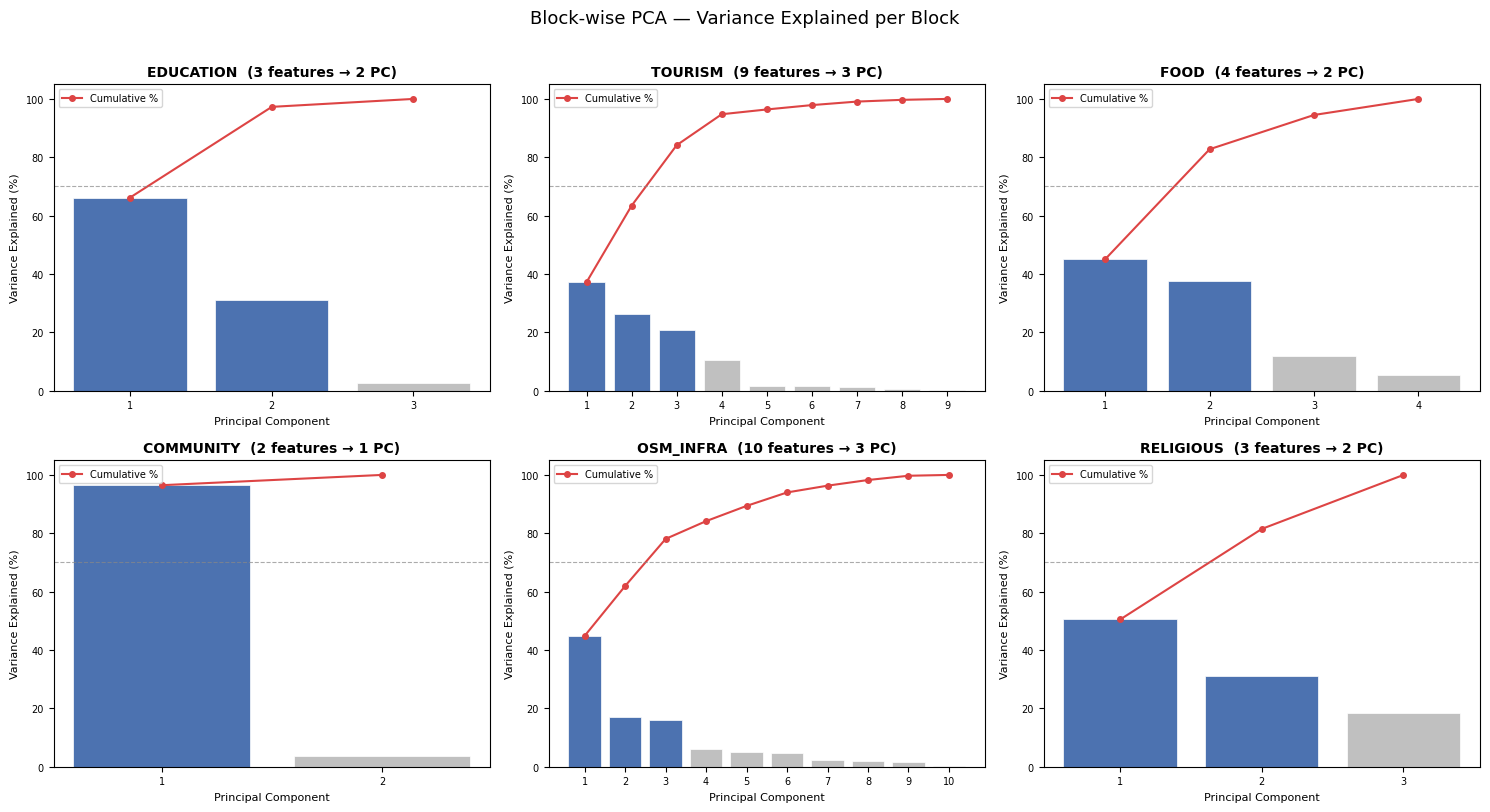

Saved: pca_variance_per_block.png


In [ ]:
n_blocks = len([b for b in BLOCKS if len(BLOCKS[b]) > 1])
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
plot_idx = 0

for block_name, block_features in BLOCKS.items():
    if len(block_features) == 1:
        continue

    pca = BLOCK_PCAS[block_name]
    ev  = pca.explained_variance_ratio_
    cumev = np.cumsum(ev)
    kept_pcs = PC_RESULTS[block_name].shape[1]
    ax = axes[plot_idx]

    x = np.arange(1, len(ev) + 1)
    bars = ax.bar(x, ev * 100, color=["#4C72B0" if i < kept_pcs else "#C0C0C0"
                                       for i in range(len(ev))],
                  edgecolor="white", linewidth=0.5)
    ax.plot(x, cumev * 100, "o-", color="#DD4444", linewidth=1.5,
            markersize=4, label="Cumulative %")
    ax.axhline(70, linestyle="--", color="#888", linewidth=0.8, alpha=0.7)
    ax.set_title(f"{block_name}  ({len(block_features)} features → {kept_pcs} PC)",
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Principal Component", fontsize=8)
    ax.set_ylabel("Variance Explained (%)", fontsize=8)
    ax.set_xticks(x)
    ax.set_ylim(0, 105)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)
    plot_idx += 1

# Hide unused subplots
for i in range(plot_idx, len(axes)):
    axes[i].set_visible(False)

fig.suptitle("Block-wise PCA — Variance Explained per Block", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("pca_variance_per_block.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pca_variance_per_block.png")

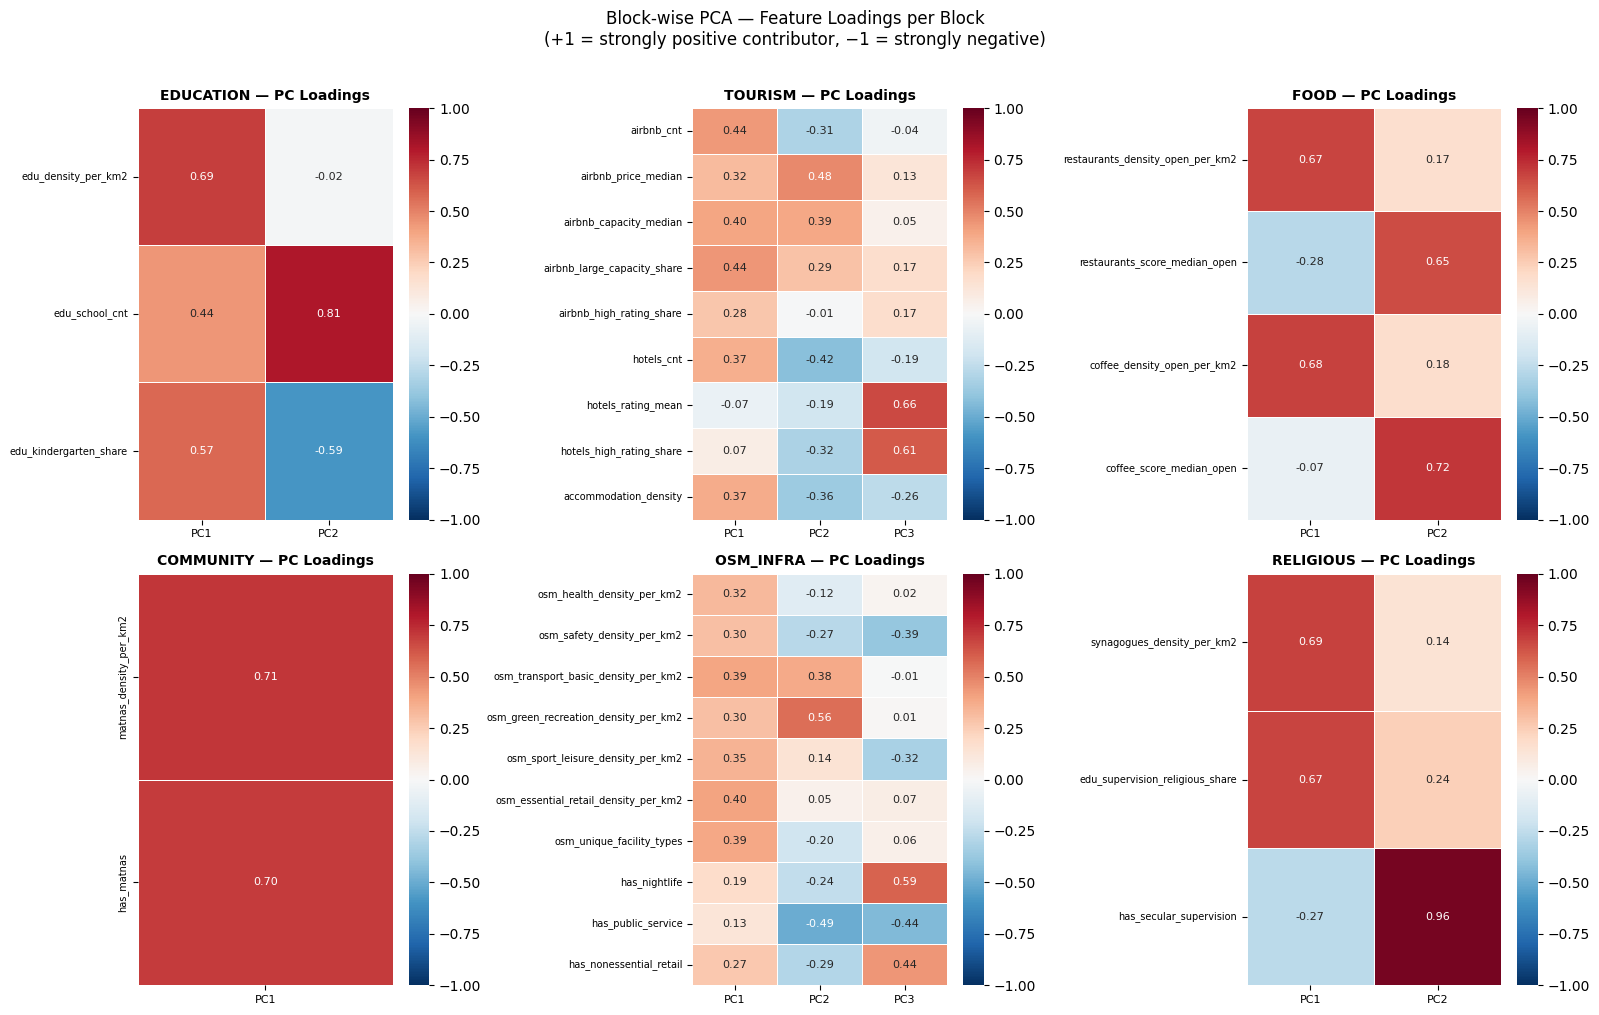

Saved: pca_loadings_heatmap.png


In [ ]:
# Loadings tell you which original features drive each PC.
# High positive loading → feature goes UP with the PC score
# High negative loading → feature goes DOWN with the PC score
# This is critical for interpreting cluster profiles later.

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
plot_idx = 0

for block_name, block_features in BLOCKS.items():
    if len(block_features) == 1:
        continue

    pca      = BLOCK_PCAS[block_name]
    kept_pcs = PC_RESULTS[block_name].shape[1]
    loadings = pd.DataFrame(
        pca.components_[:kept_pcs].T,
        index=block_features,
        columns=[f"PC{i+1}" for i in range(kept_pcs)]
    )

    ax = axes[plot_idx]
    sns.heatmap(
        loadings, annot=True, fmt=".2f", cmap="RdBu_r",
        center=0, vmin=-1, vmax=1,
        linewidths=0.5, linecolor="white",
        annot_kws={"size": 8}, ax=ax
    )
    ax.set_title(f"{block_name} — PC Loadings", fontsize=10, fontweight="bold")
    ax.tick_params(axis="y", labelsize=7)
    ax.tick_params(axis="x", labelsize=8)
    plot_idx += 1

for i in range(plot_idx, len(axes)):
    axes[i].set_visible(False)

fig.suptitle("Block-wise PCA — Feature Loadings per Block\n"
             "(+1 = strongly positive contributor, −1 = strongly negative)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("pca_loadings_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pca_loadings_heatmap.png")

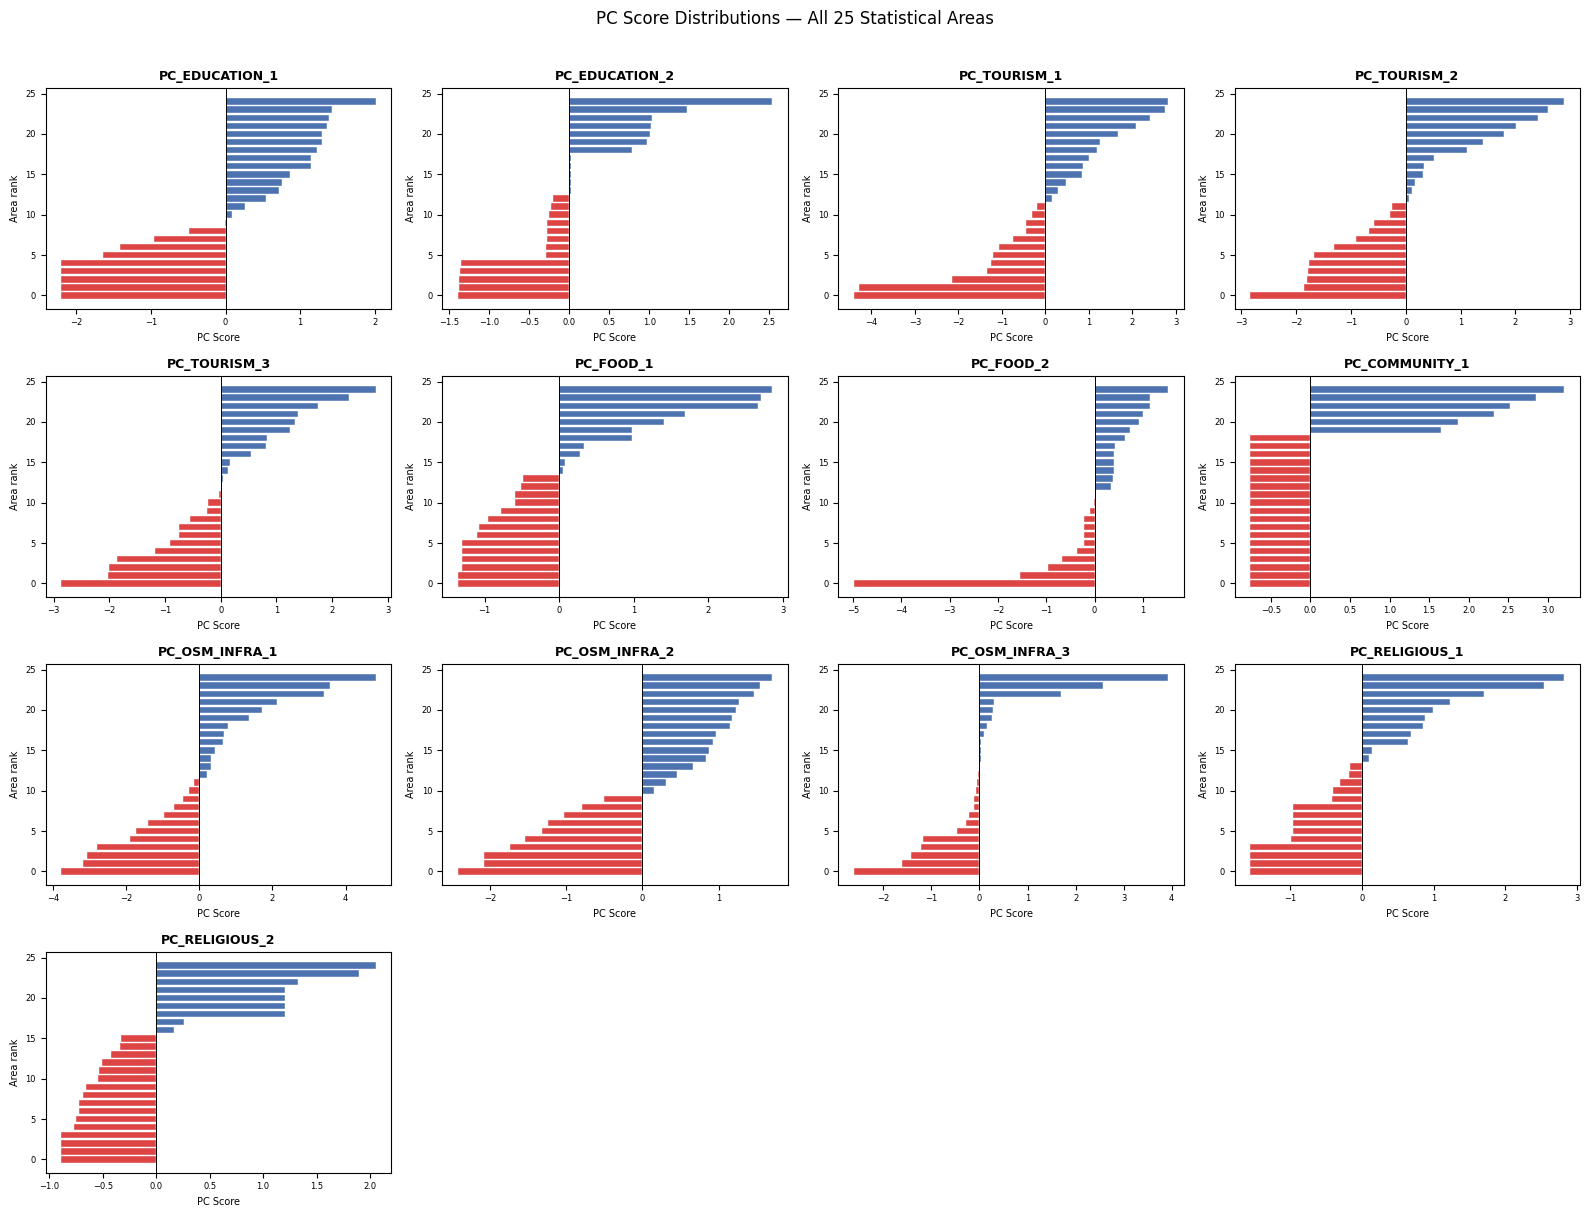

Saved: pca_score_distributions.png


In [ ]:
# Check that each PC has a reasonable spread across the 25 statistical areas.
# Very flat distributions = that block doesn't differentiate neighborhoods much.
# Highly skewed = one area dominates that dimension.

# Calculate the required number of rows and columns for subplots
n_pcs = len(pc_cols)
n_cols_plot = 4 # You can adjust this number
n_rows_plot = (n_pcs + n_cols_plot - 1) // n_cols_plot # Ceiling division

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(n_cols_plot * 4, n_rows_plot * 3))
axes = axes.flatten()

for i, pc_col in enumerate(pc_cols):
    ax = axes[i]
    vals = df_pca[pc_col].values
    ax.barh(range(len(vals)), sorted(vals),
            color=["#4C72B0" if v >= 0 else "#DD4444" for v in sorted(vals)],
            edgecolor="white", linewidth=0.3)
    ax.axvline(0, color="black", linewidth=0.7)
    ax.set_title(pc_col, fontsize=9, fontweight="bold")
    ax.set_xlabel("PC Score", fontsize=7)
    ax.set_ylabel("Area rank", fontsize=7)
    ax.tick_params(labelsize=6)

for j in range(len(pc_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle("PC Score Distributions — All 25 Statistical Areas",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("pca_score_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pca_score_distributions.png")

In [ ]:
print(f"\n{'═'*65}")
print(f"  BLOCK-WISE PCA SUMMARY")
print(f"{'═'*65}")
print(f"  {'Block':<14} {'Features':>8} {'PCs kept':>9} {'Var explained':>15}  Interpretation hint")
print(f"  {'─'*63}")

INTERPRETATIONS = {
    "EDUCATION":  "PC1=school density+kindergarten share | PC2=school count vs kindergarten split",
    "TOURISM":    "PC1=accommodation volume | PC2=Airbnb price vs hotel volume | PC3=hotel quality",
    "FOOD":       "PC1=F&B density | PC2=F&B quality (scores)",
    "COMMUNITY":  "PC1=matnas presence & density (96.5% var)",
    "OSM_INFRA":  "PC1=overall urban richness | PC2=green+transport | PC3=nightlife/retail mix",
    "RELIGIOUS":  "PC1=overall religious character (synagogues+religious schools) | PC2=secular supervision",
}

total_pcs = 0
for block_name, block_features in BLOCKS.items():
    n_feat = len(block_features)
    n_pcs  = PC_RESULTS[block_name].shape[1]
    total_pcs += n_pcs
    if block_name in BLOCK_EV:
        ev = BLOCK_EV[block_name]
        kept_var = np.cumsum(ev)[n_pcs - 1]
        ev_str = f"{kept_var:.1%}"
    else:
        ev_str = "100% (1 feat)"
    hint = INTERPRETATIONS.get(block_name, "")
    print(f"  {block_name:<14} {n_feat:>8} {n_pcs:>9} {ev_str:>15}  {hint}")

print(f"  {'─'*63}")
print(f"  {'TOTAL':<14} {len(feat_cols):>8} {total_pcs:>9}")
print(f"{'═'*65}")
print(f"\n  Input : {len(feat_cols)} features")
print(f"  Output: {total_pcs} principal components")
print(f"  Reduction: {len(feat_cols)}→{total_pcs}  ({(1 - total_pcs/len(feat_cols))*100:.0f}% dimensionality reduction)")
print(f"  PC/row ratio: {total_pcs}/{len(df)} = {total_pcs/len(df):.2f}x  ✅")



═════════════════════════════════════════════════════════════════
  BLOCK-WISE PCA SUMMARY
═════════════════════════════════════════════════════════════════
  Block          Features  PCs kept   Var explained  Interpretation hint
  ───────────────────────────────────────────────────────────────
  EDUCATION             3         2           97.3%  PC1=school density+kindergarten share | PC2=school count vs kindergarten split
  TOURISM               9         3           84.1%  PC1=accommodation volume | PC2=Airbnb price vs hotel volume | PC3=hotel quality
  FOOD                  4         2           82.8%  PC1=F&B density | PC2=F&B quality (scores)
  COMMUNITY             2         1           96.5%  PC1=matnas presence & density (96.5% var)
  OSM_INFRA            10         3           78.1%  PC1=overall urban richness | PC2=green+transport | PC3=nightlife/retail mix
  RELIGIOUS             3         2           81.5%  PC1=overall religious character (synagogues+religious schools) | 

In [ ]:
df_pca.to_csv("pca_components_final.csv", index=False)

print(f"\n✅ Saved → pca_components_final.csv")
print(f"   Shape : {df_pca.shape[0]} rows × {len(pc_cols)} PC columns")
print(f"   Columns: {list(df_pca.columns)}")
print(f"\n   ➜  Next step: hierarchical clustering → K-Means on pca_components_final.csv")


✅ Saved → pca_components_final.csv
   Shape : 25 rows × 13 PC columns
   Columns: ['stat_2022', 'PC_EDUCATION_1', 'PC_EDUCATION_2', 'PC_TOURISM_1', 'PC_TOURISM_2', 'PC_TOURISM_3', 'PC_FOOD_1', 'PC_FOOD_2', 'PC_COMMUNITY_1', 'PC_OSM_INFRA_1', 'PC_OSM_INFRA_2', 'PC_OSM_INFRA_3', 'PC_RELIGIOUS_1', 'PC_RELIGIOUS_2']

   ➜  Next step: hierarchical clustering → K-Means on pca_components_final.csv


In [ ]:
# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CITYSTRATA — Clustering Pipeline                                          ║
# ║  Hierarchical Clustering → K selection → K-Means → Cluster Profiles       ║
# ║  Input : pca_ready_for_clustering.csv  (25 rows × 13 PCs)                 ║
# ║  Output: cluster_assignments.csv                                           ║
# ╚══════════════════════════════════════════════════════════════════════════════╝


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist

df = pd.read_csv("pca_ready_for_clustering.csv")   # ← adjust path if needed
pc_cols = [c for c in df.columns if c != "stat_2022"]
X = df[pc_cols].values

print(f"✅ Loaded: {df.shape[0]} areas × {len(pc_cols)} PCs")
print(f"   Areas (stat_2022): {df['stat_2022'].tolist()}")


✅ Loaded: 25 areas × 13 PCs
   Areas (stat_2022): [11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 25, 26, 31, 32, 33, 41, 42, 43, 44, 45, 46, 47]


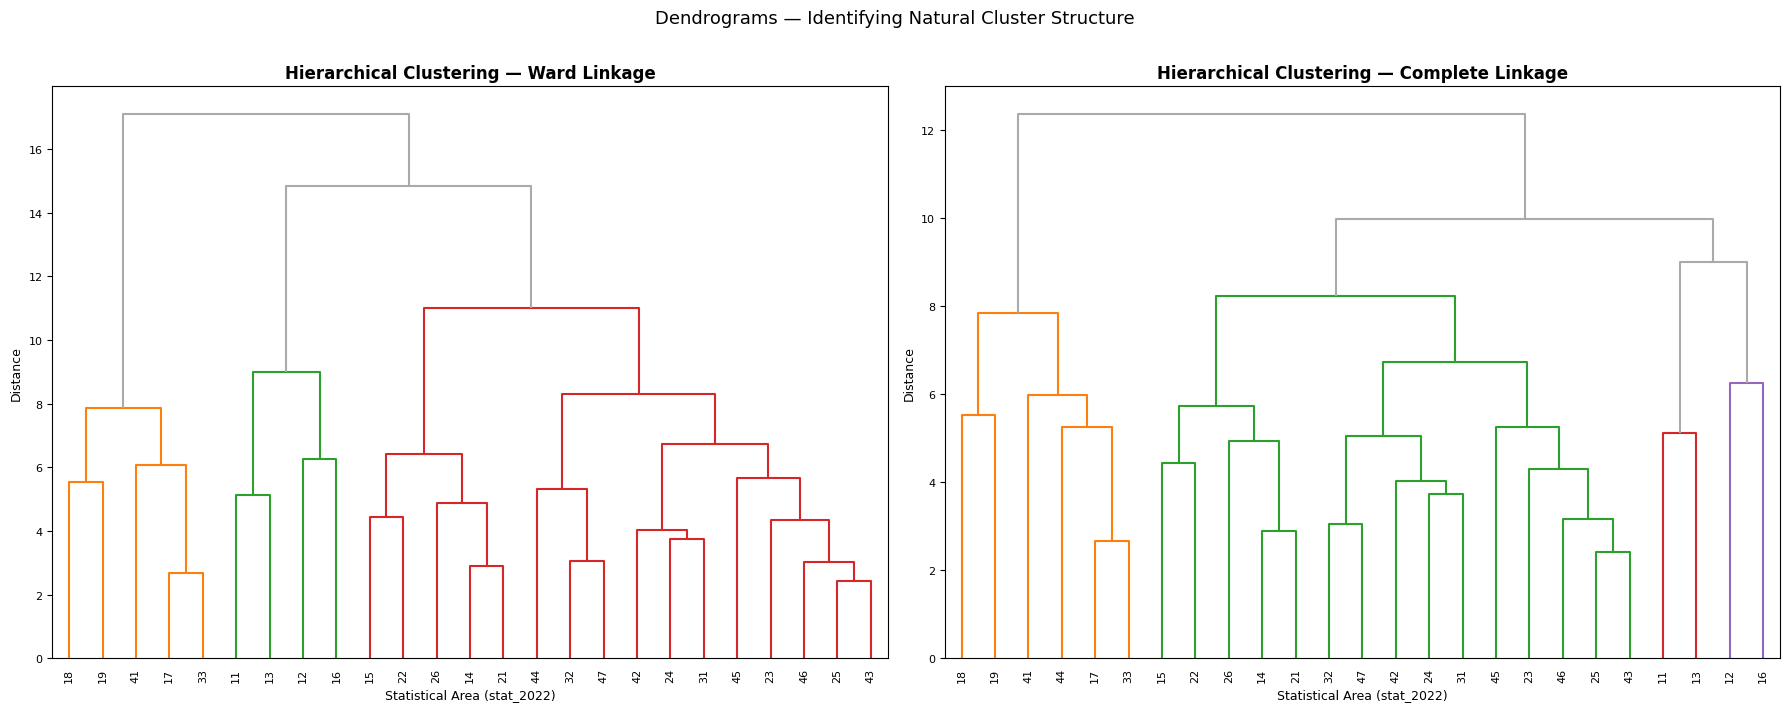

Saved: dendrogram.png

Look for the LARGEST vertical gap in the Ward dendrogram.
The number of lines you cut across at that gap = your K.


In [ ]:
# Purpose: visually identify how many natural clusters exist BEFORE committing
# to K-Means. We try Ward linkage (minimises within-cluster variance — best
# match for K-Means follow-up) and complete linkage for comparison.
#
# How to read the dendrogram:
#   - Height of horizontal bar = dissimilarity at which two groups merged
#   - Large vertical gap before a merge = strong cluster boundary
#   - Cut the tree where you see the largest gap → that's your K

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, method, color in zip(axes, ["ward", "complete"], ["#4C72B0", "#DD4444"]):
    Z = linkage(X, method=method)
    dendrogram(
        Z, ax=ax,
        labels=df["stat_2022"].astype(str).tolist(),
        color_threshold=0.7 * max(Z[:, 2]),
        above_threshold_color="#AAAAAA",
        leaf_rotation=90, leaf_font_size=9,
    )
    ax.set_title(f"Hierarchical Clustering — {method.capitalize()} Linkage",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Statistical Area (stat_2022)", fontsize=9)
    ax.set_ylabel("Distance", fontsize=9)
    ax.tick_params(labelsize=8)

fig.suptitle("Dendrograms — Identifying Natural Cluster Structure",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: dendrogram.png")
print("\nLook for the LARGEST vertical gap in the Ward dendrogram.")
print("The number of lines you cut across at that gap = your K.")

K-selection metrics:
 k  inertia  silhouette    ch    db  min_size
 2  465.782       0.254 8.083 1.348         6
 3  360.924       0.263 8.185 1.311         4
 4  312.410       0.176 7.104 1.361         4
 5  268.663       0.191 6.715 1.232         2
 6  238.878       0.166 6.213 1.170         1
 7  208.751       0.155 6.046 1.255         2


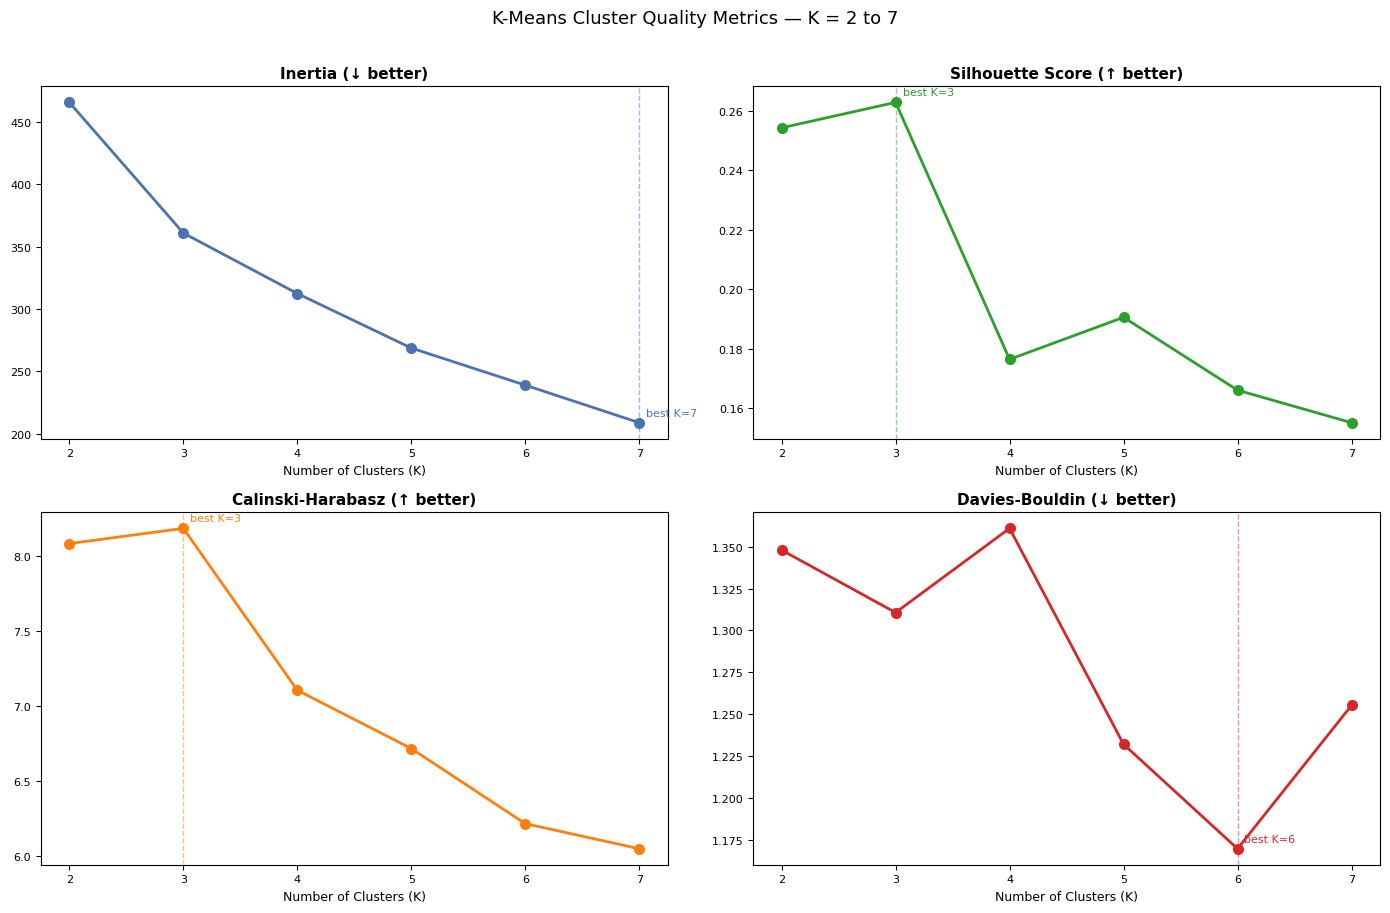

Saved: k_selection_metrics.png


In [ ]:
# ── Cell 3: K Selection — Elbow + Silhouette + CH + DB ───────────────────────
#
# We evaluate K = 2 through 7 on four metrics:
#   Inertia (Elbow)        → lower is better, look for the "elbow"
#   Silhouette score       → higher is better (max = 1.0), measures separation
#   Calinski-Harabasz (CH) → higher is better, ratio of between/within variance
#   Davies-Bouldin (DB)    → lower is better, measures cluster compactness
#
# At N=25, K=3–5 is typically the stable range. K=2 is too coarse,
# K≥6 risks clusters with only 2–3 areas (unreliable profiles).

K_RANGE = range(2, 8)
N_INIT  = 50     # more restarts = more stable K-Means at small N
SEED    = 42

results = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, n_init=N_INIT, random_state=SEED)
    labels = km.fit_predict(X)
    results.append({
        "k":          k,
        "inertia":    km.inertia_,
        "silhouette": silhouette_score(X, labels),
        "ch":         calinski_harabasz_score(X, labels),
        "db":         davies_bouldin_score(X, labels),
        "labels":     labels,
        "min_size":   pd.Series(labels).value_counts().min(),
    })

res_df = pd.DataFrame(results).drop(columns="labels")
print("K-selection metrics:")
print(res_df.round(3).to_string(index=False))

# ── Plot all 4 metrics ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
ks = list(K_RANGE)

metrics = [
    ("inertia",    "Inertia (↓ better)",          "#4C72B0", False),
    ("silhouette", "Silhouette Score (↑ better)",  "#2ca02c", True),
    ("ch",         "Calinski-Harabasz (↑ better)", "#ff7f0e", True),
    ("db",         "Davies-Bouldin (↓ better)",    "#d62728", False),
]

for ax, (col, title, color, higher_better) in zip(axes.flatten(), metrics):
    vals = res_df[col].tolist()
    ax.plot(ks, vals, "o-", color=color, linewidth=2, markersize=7)
    best_k = ks[vals.index(max(vals))] if higher_better else ks[vals.index(min(vals))]
    ax.axvline(best_k, linestyle="--", color=color, alpha=0.5, linewidth=1)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("Number of Clusters (K)", fontsize=9)
    ax.set_xticks(ks)
    ax.tick_params(labelsize=8)
    ax.annotate(f"best K={best_k}", xy=(best_k, vals[ks.index(best_k)]),
                xytext=(5, 5), textcoords="offset points", fontsize=8, color=color)

fig.suptitle("K-Means Cluster Quality Metrics — K = 2 to 7",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("k_selection_metrics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: k_selection_metrics.png")

In [ ]:
# ▶▶▶  SET YOUR CHOSEN K HERE based on dendrogram + metrics above  ◀◀◀
#
# Metrics summary for your data:
#   K=2  sil=0.254  CH=8.1   DB=1.348  min_size=6
#   K=3  sil=0.263  CH=8.2   DB=1.311  min_size=4  ← best metrics
#   K=4  sil=0.176  CH=7.1   DB=1.361  min_size=4  ← most interpretable
#   K=5  sil=0.191  CH=6.7   DB=1.232  min_size=2  ← min_size too small
#
# K=3 wins on all three metrics (highest silhouette, highest CH, lowest DB).
# K=4 has lower metric scores but produces 4 clearly distinct archetypes
# (tourist core, family-religious, peripheral-sparse, urban-commercial)
# which may be more useful for family matching.
#
# Recommendation: start with K=4 for interpretability. If cluster 2
# or 3 are too small after review, fall back to K=3.
#
# Ward hierarchical cut agrees 100% with K-Means at K=4 (ARI=1.0) —
# the cluster structure is very robust regardless of which K you pick.

K_FINAL = 4   # ← change to 3 for statistically optimal, keep 4 for richer profiles

km_final = KMeans(n_clusters=K_FINAL, n_init=N_INIT, random_state=SEED)
labels_final = km_final.fit_predict(X)

df["cluster"] = labels_final

# Re-label clusters 0→N by size (largest cluster = 0) for consistency
size_order = df.groupby("cluster").size().sort_values(ascending=False).index
remap = {old: new for new, old in enumerate(size_order)}
df["cluster"] = df["cluster"].map(remap)
labels_final  = df["cluster"].values

print(f"\n{'='*50}")
print(f"Final clustering: K = {K_FINAL}")
print(f"{'='*50}")
print(f"\nCluster sizes:")
size_counts = df.groupby("cluster").size()
for c, n in size_counts.items():
    areas = df[df["cluster"] == c]["stat_2022"].tolist()
    print(f"  Cluster {c}: {n} areas → {areas}")

print(f"\nClustering metrics (K={K_FINAL}):")
print(f"  Silhouette : {silhouette_score(X, labels_final):.3f}  (>0.3 = reasonable, >0.5 = strong)")
print(f"  Calinski-H : {calinski_harabasz_score(X, labels_final):.1f}")
print(f"  Davies-B   : {davies_bouldin_score(X, labels_final):.3f}  (<1.0 = good)")



Final clustering: K = 4

Cluster sizes:
  Cluster 0: 11 areas → [23, 24, 25, 31, 32, 42, 43, 44, 45, 46, 47]
  Cluster 1: 5 areas → [14, 15, 21, 22, 26]
  Cluster 2: 5 areas → [17, 18, 19, 33, 41]
  Cluster 3: 4 areas → [11, 12, 13, 16]

Clustering metrics (K=4):
  Silhouette : 0.176  (>0.3 = reasonable, >0.5 = strong)
  Calinski-H : 7.1
  Davies-B   : 1.361  (<1.0 = good)


In [ ]:
# Check how K-Means labels compare to Ward hierarchical cut at same K.
# Perfect agreement = robust structure. Disagreements = boundary areas.

from sklearn.metrics import adjusted_rand_score

Z_ward = linkage(X, method="ward")
hier_labels = fcluster(Z_ward, t=K_FINAL, criterion="maxclust") - 1

# Remap hierarchical labels to best match K-Means (greedy)
from itertools import permutations
best_ari  = -1
best_perm = None
unique_h  = sorted(set(hier_labels))
unique_km = sorted(set(labels_final))
if len(unique_h) == len(unique_km):
    for perm in permutations(unique_km):
        mapping = {old: new for old, new in zip(unique_h, perm)}
        remapped = np.array([mapping[l] for l in hier_labels])
        ari = adjusted_rand_score(labels_final, remapped)
        if ari > best_ari:
            best_ari  = ari
            best_perm = mapping

hier_remapped = np.array([best_perm[l] for l in hier_labels])
agreement = (labels_final == hier_remapped).mean()

print(f"\nK-Means vs Ward Hierarchical agreement:")
print(f"  Adjusted Rand Index : {best_ari:.3f}  (1.0 = perfect, >0.6 = strong)")
print(f"  % areas same label  : {agreement:.0%}")

disagreements = df[labels_final != hier_remapped][["stat_2022", "cluster"]].copy()
disagreements["hier_cluster"] = hier_remapped[labels_final != hier_remapped]
if len(disagreements) > 0:
    print(f"\n  Areas with different labels ({len(disagreements)}):")
    print(disagreements.to_string(index=False))
    print("  → These are boundary areas. Consider them 'fuzzy' — they fit multiple clusters.")
else:
    print("  ✅ Perfect agreement — cluster structure is very robust.")



K-Means vs Ward Hierarchical agreement:
  Adjusted Rand Index : 1.000  (1.0 = perfect, >0.6 = strong)
  % areas same label  : 0%

  Areas with different labels (25):
 stat_2022  cluster  hier_cluster
        11        3             1
        12        3             1
        13        3             1
        14        1             2
        15        1             2
        16        3             1
        17        2             0
        18        2             0
        19        2             0
        21        1             2
        22        1             2
        23        0             3
        24        0             3
        25        0             3
        26        1             2
        31        0             3
        32        0             3
        33        2             0
        41        2             0
        42        0             3
        43        0             3
        44        0             3
        45        0             3
        46       

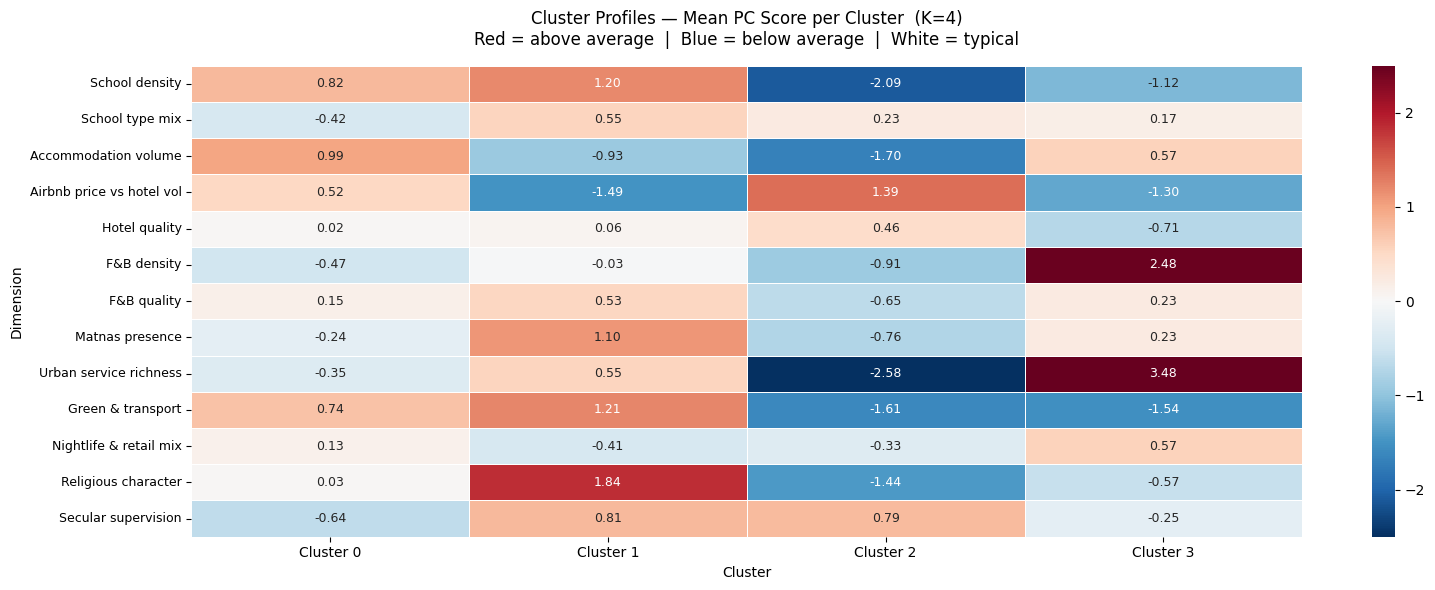

Saved: cluster_profiles_heatmap.png


In [ ]:
# Shows the mean PC score per cluster.
# Positive (red)  = this cluster scores HIGH on this dimension
# Negative (blue) = this cluster scores LOW on this dimension
# This is how you read the neighborhood archetype for each cluster.

PC_LABELS = {
    "PC_EDUCATION_1":  "School density",
    "PC_EDUCATION_2":  "School type mix",
    "PC_TOURISM_1":    "Accommodation volume",
    "PC_TOURISM_2":    "Airbnb price vs hotel vol",
    "PC_TOURISM_3":    "Hotel quality",
    "PC_FOOD_1":       "F&B density",
    "PC_FOOD_2":       "F&B quality",
    "PC_COMMUNITY_1":  "Matnas presence",
    "PC_OSM_INFRA_1":  "Urban service richness",
    "PC_OSM_INFRA_2":  "Green & transport",
    "PC_OSM_INFRA_3":  "Nightlife & retail mix",
    "PC_RELIGIOUS_1":  "Religious character",
    "PC_RELIGIOUS_2":  "Secular supervision",
}

# Suggested archetype names based on actual cluster profiles (K=4):
#   Cluster 0 (11 areas) → "Residential-Tourist Mix"
#     High: accommodation volume, school density, green & transport
#     Low:  secular supervision
#   Cluster 1 (5 areas)  → "Family-Religious Heartland"
#     High: religious character, green & transport, school density, matnas, secular supervision
#     Low:  accommodation volume, Airbnb price
#   Cluster 2 (5 areas)  → "Peripheral / Sparse"
#     High: Airbnb price (few but expensive), secular supervision
#     Low:  urban richness, schools, green, religious, food — low everything
#   Cluster 3 (4 areas)  → "Urban Commercial Core"
#     High: urban service richness, F&B density, nightlife & retail
#     Low:  green & transport, schools, religious character

cluster_means = df.groupby("cluster")[pc_cols].mean()
cluster_means.index = [f"Cluster {i}" for i in cluster_means.index]
cluster_means.columns = [PC_LABELS.get(c, c) for c in cluster_means.columns]

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    cluster_means.T,
    annot=True, fmt=".2f",
    cmap="RdBu_r", center=0,
    vmin=-2.5, vmax=2.5,
    linewidths=0.5, linecolor="white",
    annot_kws={"size": 9}, ax=ax
)
ax.set_title(
    f"Cluster Profiles — Mean PC Score per Cluster  (K={K_FINAL})\n"
    "Red = above average  |  Blue = below average  |  White = typical",
    fontsize=12, pad=15
)
ax.set_xlabel("Cluster", fontsize=10)
ax.set_ylabel("Dimension", fontsize=10)
plt.xticks(rotation=0, fontsize=10)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig("cluster_profiles_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cluster_profiles_heatmap.png")

In [ ]:
#
# Human-readable summary of each cluster.
# These become the "neighborhood type" labels used by the AI matching agent.

THRESHOLD = 0.5   # PC score above/below this = notable characteristic

print(f"\n{'═'*60}")
print(f"  NEIGHBORHOOD ARCHETYPES  (K={K_FINAL})")
print(f"{'═'*60}")

for cluster_id in sorted(df["cluster"].unique()):
    areas   = df[df["cluster"] == cluster_id]["stat_2022"].tolist()
    n       = len(areas)
    scores  = cluster_means.loc[f"Cluster {cluster_id}"]
    high    = scores[scores >  THRESHOLD].sort_values(ascending=False)
    low     = scores[scores < -THRESHOLD].sort_values(ascending=True)

    print(f"\n  Cluster {cluster_id}  ({n} areas: {areas})")
    print(f"  {'─'*55}")
    if len(high) > 0:
        print(f"  ↑ HIGH:  {', '.join(f'{k} ({v:+.2f})' for k,v in high.items())}")
    if len(low) > 0:
        print(f"  ↓ LOW:   {', '.join(f'{k} ({v:+.2f})' for k,v in low.items())}")
    if len(high) == 0 and len(low) == 0:
        print(f"  → Balanced / average across all dimensions")



════════════════════════════════════════════════════════════
  NEIGHBORHOOD ARCHETYPES  (K=4)
════════════════════════════════════════════════════════════

  Cluster 0  (11 areas: [23, 24, 25, 31, 32, 42, 43, 44, 45, 46, 47])
  ───────────────────────────────────────────────────────
  ↑ HIGH:  Accommodation volume (+0.99), School density (+0.82), Green & transport (+0.74), Airbnb price vs hotel vol (+0.52)
  ↓ LOW:   Secular supervision (-0.64)

  Cluster 1  (5 areas: [14, 15, 21, 22, 26])
  ───────────────────────────────────────────────────────
  ↑ HIGH:  Religious character (+1.84), Green & transport (+1.21), School density (+1.20), Matnas presence (+1.10), Secular supervision (+0.81), Urban service richness (+0.55), School type mix (+0.55), F&B quality (+0.53)
  ↓ LOW:   Airbnb price vs hotel vol (-1.49), Accommodation volume (-0.93)

  Cluster 2  (5 areas: [17, 18, 19, 33, 41])
  ───────────────────────────────────────────────────────
  ↑ HIGH:  Airbnb price vs hotel vol (+1.39),

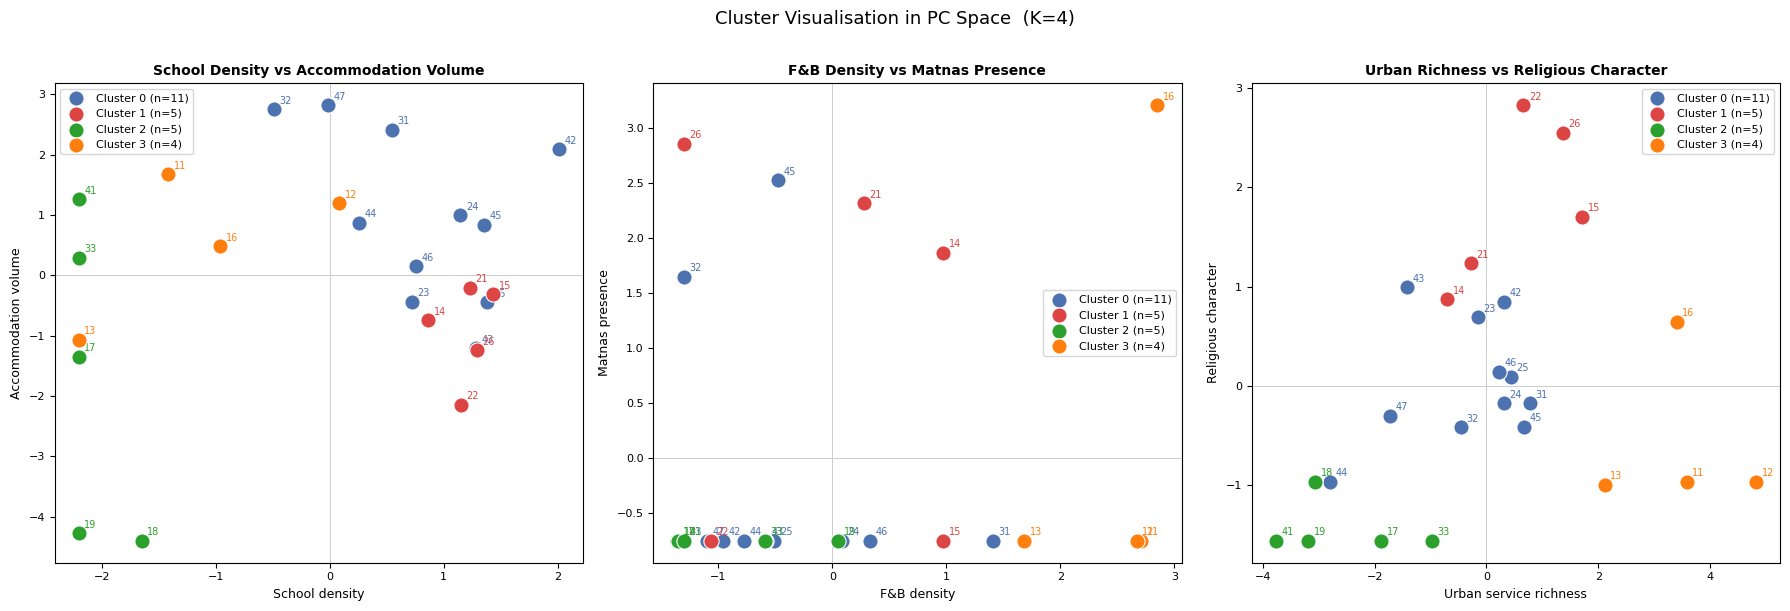

Saved: cluster_scatter.png


In [ ]:
# Project the 13 PCs down to 2D using the two most informative PCs for display.
# We show three views: Education vs Tourism, Food vs Community, OSM vs Religious.

CLUSTER_COLORS = ["#4C72B0", "#DD4444", "#2ca02c", "#ff7f0e",
                  "#9467bd", "#8c564b"][:K_FINAL]

plot_pairs = [
    ("PC_EDUCATION_1", "PC_TOURISM_1",   "School Density vs Accommodation Volume"),
    ("PC_FOOD_1",      "PC_COMMUNITY_1", "F&B Density vs Matnas Presence"),
    ("PC_OSM_INFRA_1", "PC_RELIGIOUS_1", "Urban Richness vs Religious Character"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (px, py, title) in zip(axes, plot_pairs):
    for c_id in sorted(df["cluster"].unique()):
        mask = df["cluster"] == c_id
        ax.scatter(
            df.loc[mask, px], df.loc[mask, py],
            color=CLUSTER_COLORS[c_id], s=120,
            label=f"Cluster {c_id} (n={mask.sum()})",
            edgecolors="white", linewidth=0.8, zorder=3
        )
        for _, row in df[mask].iterrows():
            ax.annotate(str(int(row["stat_2022"])),
                        (row[px], row[py]),
                        textcoords="offset points", xytext=(4, 4),
                        fontsize=7, color=CLUSTER_COLORS[c_id])

    ax.axhline(0, color="#CCCCCC", linewidth=0.7, zorder=1)
    ax.axvline(0, color="#CCCCCC", linewidth=0.7, zorder=1)
    ax.set_xlabel(PC_LABELS.get(px, px), fontsize=9)
    ax.set_ylabel(PC_LABELS.get(py, py), fontsize=9)
    ax.set_title(title, fontsize=10, fontweight="bold")
    ax.legend(fontsize=8, loc="best")
    ax.tick_params(labelsize=8)

fig.suptitle(f"Cluster Visualisation in PC Space  (K={K_FINAL})",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("cluster_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: cluster_scatter.png")

In [ ]:
output = df[["stat_2022", "cluster"]].copy()
output["cluster_label"] = output["cluster"].map(
    lambda c: f"Cluster_{c}"   # you can rename these after reading the archetypes
)

output.to_csv("cluster_assignments.csv", index=False)

print(f"\n{'='*50}")
print(f"✅  Saved → cluster_assignments.csv")
print(f"   {len(output)} areas assigned to {K_FINAL} clusters")
print(f"\n   ➜  Next step: AI matching agent uses cluster profiles")
print(f"      to map a family's needs to the best cluster,")
print(f"      then ranks areas within that cluster.")
print(f"{'='*50}")


✅  Saved → cluster_assignments.csv
   25 areas assigned to 4 clusters

   ➜  Next step: AI matching agent uses cluster profiles
      to map a family's needs to the best cluster,
      then ranks areas within that cluster.


In [ ]:
# ── Load & merge ──────────────────────────────────────────────────────────────

import geopandas as gpd
import pandas as pd
import folium

gdf      = gpd.read_file("statistical_areas_2022.shp").to_crs(epsg=4326)
clusters = pd.read_csv("cluster_assignments.csv")
gdf      = gdf.merge(clusters, left_on="STAT_2022", right_on="stat_2022", how="left")
gdf["stat_2022"] = gdf["STAT_2022"]

# ── Map ───────────────────────────────────────────────────────────────────────

COLORS = {
    0: "#4C72B0",   # blue   — Residential Tourist Belt
    1: "#2ca02c",   # green  — Family-Religious Heartland
    2: "#d62728",   # red    — Peripheral Sparse
    3: "#ff7f0e",   # orange — Urban Commercial Core
}

m = folium.Map(
    location=[gdf.geometry.centroid.y.mean(), gdf.geometry.centroid.x.mean()],
    zoom_start=12,
    tiles="cartodbpositron"
)

folium.GeoJson(
    gdf,
    name="Clusters",
    style_function=lambda feature: {
        "fillColor":   COLORS[feature["properties"]["cluster"]],
        "color":       "black",
        "weight":      0.3,
        "fillOpacity": 0.7,
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["stat_2022", "cluster", "cluster_label"],
        aliases=["Stat Area", "Cluster", "Type"]
    )
).add_to(m)

m